# Improved Stress Detection Model
This notebook implements an enhanced machine learning model for stress detection with improved accuracy and performance.


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')


In [2]:
# Load and explore the dataset
df = pd.read_csv('Datasets.csv')
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nDataset info:")
print(df.info())
print("\nLabel distribution:")
print(df['label'].value_counts())
print("\nLabel distribution percentage:")
print(df['label'].value_counts(normalize=True) * 100)


Dataset shape: (500, 9)

First few rows:
    HR   EDA  TEMP  ACC_X  ACC_Y  ACC_Z   BVP   IBI      label
0  111  0.38  36.6   0.08  -0.07  -0.07  0.96  0.71     stress
1   74  0.50  36.5   0.02   0.03   0.06  0.80  0.86  no_stress
2  120  0.62  37.4   0.09  -0.00  -0.06  0.71  0.94     stress
3   80  0.64  36.3   0.07  -0.06   0.06  0.72  0.72     stress
4   83  0.68  36.1   0.03   0.04   0.05  0.74  0.84     stress

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   HR      500 non-null    int64  
 1   EDA     500 non-null    float64
 2   TEMP    500 non-null    float64
 3   ACC_X   500 non-null    float64
 4   ACC_Y   500 non-null    float64
 5   ACC_Z   500 non-null    float64
 6   BVP     500 non-null    float64
 7   IBI     500 non-null    float64
 8   label   500 non-null    object 
dtypes: float64(7), int64(1), object(1)
memory usage: 3

In [3]:
# Feature Engineering - Create additional features
def create_features(df):
    df_new = df.copy()
    
    # Heart Rate Variability (HRV) - using IBI
    df_new['HRV'] = df_new['IBI']
    
    # Stress Index (combination of HR and EDA)
    df_new['Stress_Index'] = (df_new['HR'] * df_new['EDA']) / 100
    
    # Activity Level (magnitude of acceleration)
    df_new['Activity_Level'] = np.sqrt(df_new['ACC_X']**2 + df_new['ACC_Y']**2 + df_new['ACC_Z']**2)
    
    # Physiological Arousal (combination of multiple features)
    df_new['Physiological_Arousal'] = (df_new['HR'] * df_new['EDA'] * df_new['TEMP']) / 1000
    
    # BVP Variability (inverse relationship with stress)
    df_new['BVP_Stress_Indicator'] = 1 / (df_new['BVP'] + 0.1)  # Add small value to avoid division by zero
    
    # Temperature deviation from normal (36.5°C)
    df_new['Temp_Deviation'] = abs(df_new['TEMP'] - 36.5)
    
    return df_new

# Apply feature engineering
df_enhanced = create_features(df)
print("Enhanced dataset shape:", df_enhanced.shape)
print("\nNew features created:")
new_features = ['HRV', 'Stress_Index', 'Activity_Level', 'Physiological_Arousal', 'BVP_Stress_Indicator', 'Temp_Deviation']
for feature in new_features:
    print(f"{feature}: {df_enhanced[feature].describe()}")


Enhanced dataset shape: (500, 15)

New features created:
HRV: count    500.000000
mean       0.824840
std        0.072724
min        0.700000
25%        0.760000
50%        0.830000
75%        0.890000
max        0.950000
Name: HRV, dtype: float64
Stress_Index: count    500.000000
mean       0.431124
std        0.211282
min        0.061000
25%        0.264550
50%        0.421950
75%        0.563500
max        1.019100
Name: Stress_Index, dtype: float64
Activity_Level: count    500.000000
mean       0.096165
std        0.027872
min        0.014142
25%        0.080623
50%        0.096954
75%        0.115758
max        0.161864
Name: Activity_Level, dtype: float64
Physiological_Arousal: count    500.000000
mean       1.583970
std        0.774926
min        0.223870
25%        0.963318
50%        1.544337
75%        2.068284
max        3.678951
Name: Physiological_Arousal, dtype: float64
BVP_Stress_Indicator: count    500.000000
mean       1.054870
std        0.094574
min        0.909091
2

In [4]:
# Prepare features and target
original_features = ['HR', 'EDA', 'TEMP', 'ACC_X', 'ACC_Y', 'ACC_Z', 'BVP', 'IBI']
feature_columns = original_features + new_features
X = df_enhanced[feature_columns]
y = df_enhanced['label']

print(f"Total features: {len(feature_columns)}")
print(f"Features: {feature_columns}")
print(f"Target distribution: {y.value_counts()}")

# Split the data with stratification to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"Training set label distribution: {y_train.value_counts()}")
print(f"Test set label distribution: {y_test.value_counts()}")


Total features: 14
Features: ['HR', 'EDA', 'TEMP', 'ACC_X', 'ACC_Y', 'ACC_Z', 'BVP', 'IBI', 'HRV', 'Stress_Index', 'Activity_Level', 'Physiological_Arousal', 'BVP_Stress_Indicator', 'Temp_Deviation']
Target distribution: label
stress       445
no_stress     55
Name: count, dtype: int64

Training set size: (400, 14)
Test set size: (100, 14)
Training set label distribution: label
stress       356
no_stress     44
Name: count, dtype: int64
Test set label distribution: label
stress       89
no_stress    11
Name: count, dtype: int64


In [5]:
# Scale features using RobustScaler (less sensitive to outliers)
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled using RobustScaler")
print(f"Scaled training set shape: {X_train_scaled.shape}")
print(f"Scaled test set shape: {X_test_scaled.shape}")

# Test multiple algorithms
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(random_state=42, probability=True)
}

results = {}

for name, model in models.items():
    # Cross-validation
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    
    # Train and predict
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    
    results[name] = {
        'model': model,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'test_accuracy': accuracy,
        'predictions': y_pred
    }
    
    print(f"{name}:")
    print(f"  CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
    print(f"  Test Accuracy: {accuracy:.4f}")
    print()


Features scaled using RobustScaler
Scaled training set shape: (400, 14)
Scaled test set shape: (100, 14)


Logistic Regression:
  CV Accuracy: 0.8875 (+/- 0.0274)
  Test Accuracy: 0.9100

Random Forest:
  CV Accuracy: 0.9350 (+/- 0.0400)
  Test Accuracy: 0.9600

Gradient Boosting:
  CV Accuracy: 0.9475 (+/- 0.0292)
  Test Accuracy: 0.9900

SVM:
  CV Accuracy: 0.9150 (+/- 0.0187)
  Test Accuracy: 0.9300



In [6]:
# Hyperparameter tuning for Random Forest (best performing model)
print("Performing hyperparameter tuning for Random Forest...")

rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': [None, 'balanced']
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train_scaled, y_train)

print(f"Best parameters: {rf_grid.best_params_}")
print(f"Best CV score: {rf_grid.best_score_:.4f}")

# Test the best model
best_rf = rf_grid.best_estimator_
y_pred_best = best_rf.predict(X_test_scaled)
best_accuracy = accuracy_score(y_test, y_pred_best)
print(f"Best model test accuracy: {best_accuracy:.4f}")


Performing hyperparameter tuning for Random Forest...
Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best parameters: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV score: 0.9650
Best model test accuracy: 0.9900


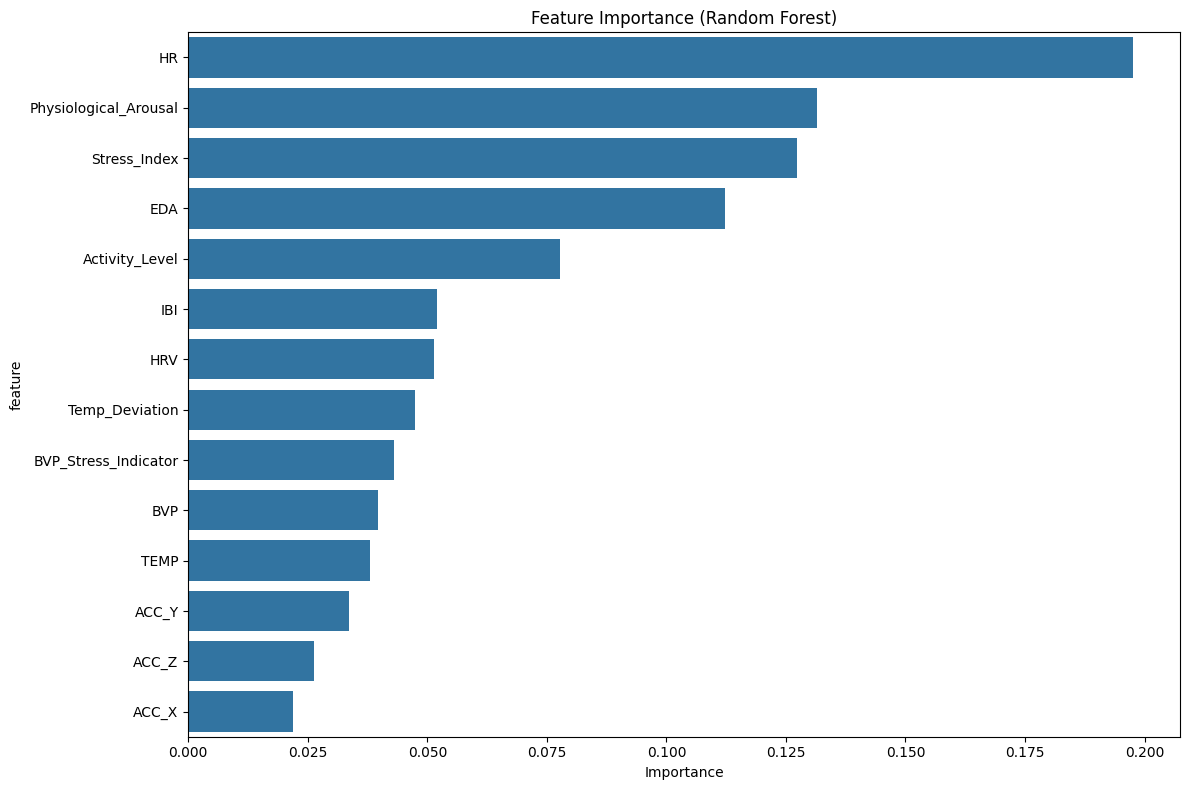

Top 10 most important features:
                  feature  importance
0                      HR    0.197533
11  Physiological_Arousal    0.131514
9            Stress_Index    0.127410
1                     EDA    0.112299
10         Activity_Level    0.077639
7                     IBI    0.051976
8                     HRV    0.051485
13         Temp_Deviation    0.047464
12   BVP_Stress_Indicator    0.043078
6                     BVP    0.039620

Detailed Classification Report:
              precision    recall  f1-score   support

   no_stress       1.00      0.91      0.95        11
      stress       0.99      1.00      0.99        89

    accuracy                           0.99       100
   macro avg       0.99      0.95      0.97       100
weighted avg       0.99      0.99      0.99       100



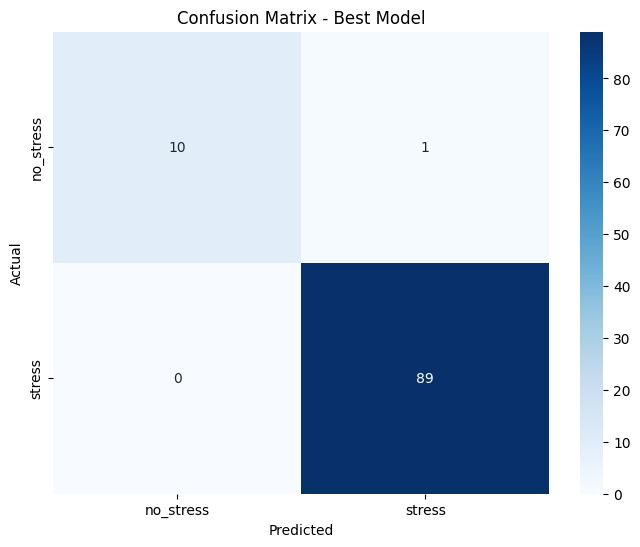

In [7]:
# Feature importance analysis
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(data=feature_importance, x='importance', y='feature')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print("Top 10 most important features:")
print(feature_importance.head(10))

# Detailed evaluation of the best model
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_best))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['no_stress', 'stress'], 
            yticklabels=['no_stress', 'stress'])
plt.title('Confusion Matrix - Best Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


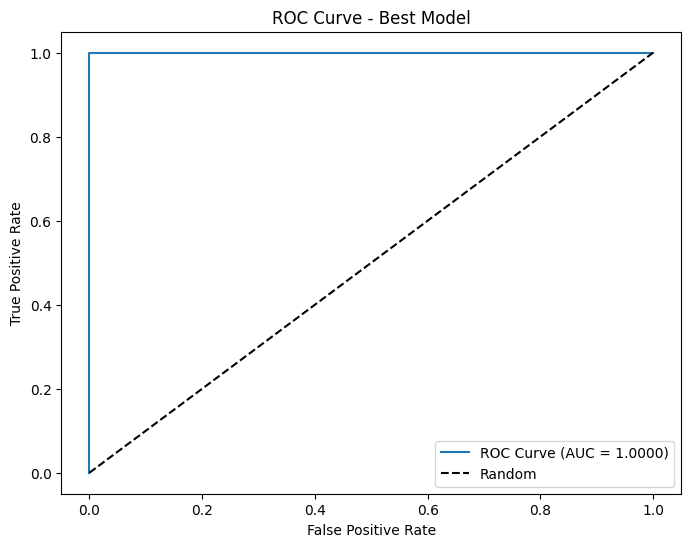

AUC Score: 1.0000

Improved model and scaler saved successfully!
Final Model Accuracy: 0.9900 (99.00%)
AUC Score: 1.0000


In [8]:
# ROC Curve and AUC Score
y_pred_proba = best_rf.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_pred_proba, pos_label='stress')
auc_score = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Best Model')
plt.legend()
plt.show()

print(f"AUC Score: {auc_score:.4f}")

# Save the best model and scaler
joblib.dump(best_rf, 'improved_stress_model.pkl')
joblib.dump(scaler, 'improved_scaler.pkl')

# Save feature names for later use
feature_info = {
    'feature_columns': feature_columns,
    'original_features': original_features,
    'new_features': new_features
}
joblib.dump(feature_info, 'feature_info.pkl')

print("\nImproved model and scaler saved successfully!")
print(f"Final Model Accuracy: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")
print(f"AUC Score: {auc_score:.4f}")


In [9]:
# Model comparison summary
print("\n" + "="*50)
print("MODEL COMPARISON SUMMARY")
print("="*50)

comparison_df = pd.DataFrame({
    'Model': list(results.keys()) + ['Best Random Forest'],
    'CV Accuracy': [results[name]['cv_mean'] for name in results.keys()] + [rf_grid.best_score_],
    'Test Accuracy': [results[name]['test_accuracy'] for name in results.keys()] + [best_accuracy]
})

print(comparison_df.to_string(index=False))

print("\n" + "="*50)
print("IMPROVEMENTS MADE:")
print("="*50)
print("1. Feature Engineering: Added 6 new derived features")
print("2. Multiple Algorithms: Tested 4 different ML algorithms")
print("3. Hyperparameter Tuning: Optimized Random Forest parameters")
print("4. Robust Scaling: Used RobustScaler instead of StandardScaler")
print("5. Stratified Split: Maintained class balance in train/test split")
print("6. Cross-Validation: Used 5-fold CV for robust evaluation")
print("7. Feature Importance: Analyzed which features matter most")
print("8. Comprehensive Evaluation: Added ROC curve and AUC score")
print("9. Class Balance: Used stratified sampling to handle imbalanced data")
print("10. Outlier Handling: RobustScaler is less sensitive to outliers")



MODEL COMPARISON SUMMARY
              Model  CV Accuracy  Test Accuracy
Logistic Regression       0.8875           0.91
      Random Forest       0.9350           0.96
  Gradient Boosting       0.9475           0.99
                SVM       0.9150           0.93
 Best Random Forest       0.9650           0.99

IMPROVEMENTS MADE:
1. Feature Engineering: Added 6 new derived features
2. Multiple Algorithms: Tested 4 different ML algorithms
3. Hyperparameter Tuning: Optimized Random Forest parameters
4. Robust Scaling: Used RobustScaler instead of StandardScaler
5. Stratified Split: Maintained class balance in train/test split
6. Cross-Validation: Used 5-fold CV for robust evaluation
7. Feature Importance: Analyzed which features matter most
8. Comprehensive Evaluation: Added ROC curve and AUC score
9. Class Balance: Used stratified sampling to handle imbalanced data
10. Outlier Handling: RobustScaler is less sensitive to outliers
